In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Data\Raw\online_retail_II.csv')

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.shape

(1067371, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [6]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [7]:
df['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER    5918
REGENCY CAKESTAND 3 TIER              4412
JUMBO BAG RED RETROSPOT               3469
ASSORTED COLOUR BIRD ORNAMENT         2958
PARTY BUNTING                         2765
                                      ... 
wet?                                     1
lost??                                   1
???                                      1
wet boxes                                1
????damages????                          1
Name: count, Length: 5698, dtype: int64

In [8]:
items = df['Description'].unique()
items

<StringArray>
['15CM CHRISTMAS GLASS BALL 20 LIGHTS',                  'PINK CHERRY LIGHTS',
                ' WHITE CHERRY LIGHTS',        'RECORD FRAME 7" SINGLE SIZE ',
      'STRAWBERRY CERAMIC TRINKET BOX',          'PINK DOUGHNUT TRINKET POT ',
                 'SAVE THE PLANET MUG',  'FANCY FONT HOME SWEET HOME DOORMAT',
                           'CAT BOWL ',      'DOG BOWL , CHASING BALL DESIGN',
 ...
      'SET 10 CARDS SNOWY ROBIN 17099', 'SET 10 CARDS SWIRLY XMAS TREE 17104',
                                'wet?',                              'lost??',
                                 '???',                           'wet boxes',
                     '????damages????',                            'mixed up',
  'CREAM HANGING HEART T-LIGHT HOLDER',         'PAPER CRAFT , LITTLE BIRDIE']
Length: 5699, dtype: str

In [9]:
# creating sales columns sales = qty*price
df['Sales'] = df['Quantity'] * df['Price']
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


# Distribution Analysis

In [10]:
df["Price"].describe()



count    1.067371e+06
mean     4.649388e+00
std      1.235531e+02
min     -5.359436e+04
25%      1.250000e+00
50%      2.100000e+00
75%      4.150000e+00
max      3.897000e+04
Name: Price, dtype: float64

In [11]:
(df["Price"] <= 0).sum()

np.int64(6207)

In [12]:
df["Price"].nlargest(10)

748142     38970.00
241824     25111.09
241827     25111.09
320581     18910.69
1050063    17836.46
569163     16888.02
569164     16453.71
517953     13541.33
517955     13541.33
519294     13541.33
Name: Price, dtype: float64

<Axes: xlabel='Quantity'>

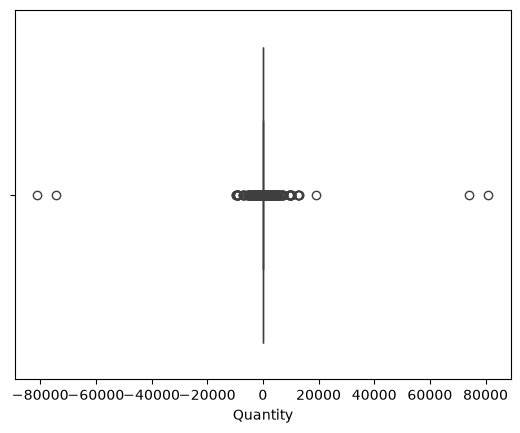

In [13]:
#Quantity Boxplot
sns.boxplot(x=df["Quantity"])


<Axes: xlabel='Price'>

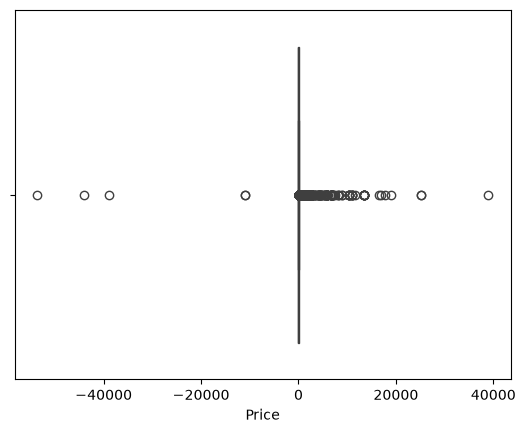

In [14]:
sns.boxplot(x=df["Price"])

<Axes: xlabel='Sales'>

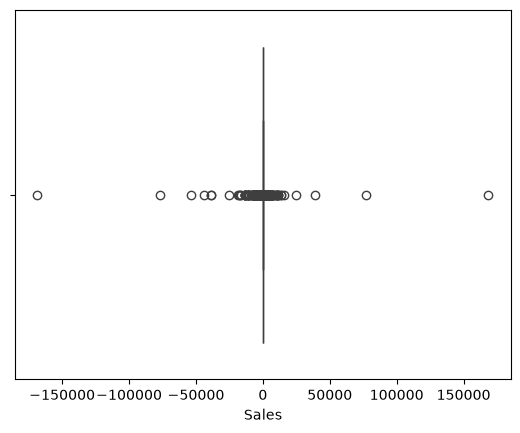

In [15]:
sns.boxplot(x=df["Sales"])

In [16]:
#Customer Spending Distribution
customer_sales = (
    df.groupby("Customer ID")
      ["Sales"]
      .sum()
)

<Axes: xlabel='Sales', ylabel='Count'>

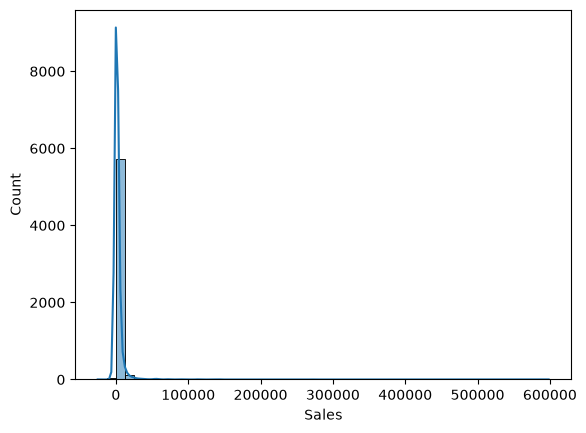

In [17]:
sns.histplot(
    customer_sales,
    bins=50,
    kde=True
)

<Axes: xlabel='Invoice', ylabel='Count'>

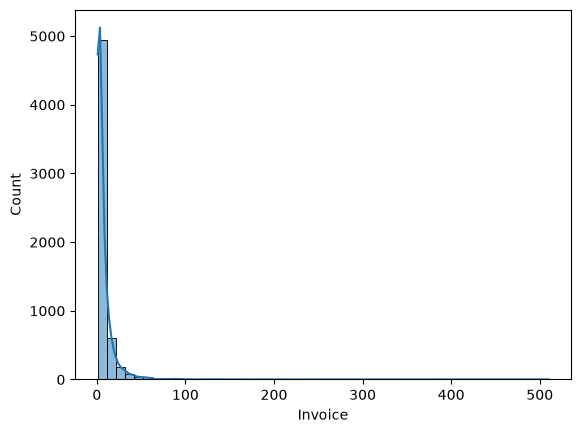

In [18]:
#Order Frequency Distribution
order_frequency = (
    df.groupby("Customer ID")
      ["Invoice"]
      .nunique()
)
sns.histplot(
    order_frequency,
    bins=50,
    kde=True
)

<Axes: xlabel='Country'>

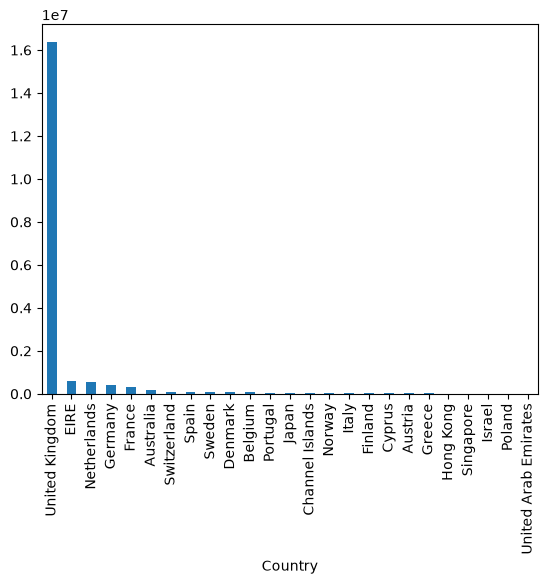

In [19]:
#Country Distribution
country_sales = (
    df.groupby("Country")
      ["Sales"]
      .sum()
      .sort_values(
          ascending=False
      )
).head(25)

country_sales.plot(
    kind="bar"
)

# Data Cleaning

In [20]:
#check missing values
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
Sales               0
dtype: int64

In [21]:
#remove missing customer ids
df = df.dropna(subset=["Customer ID"])

In [22]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Sales          0
dtype: int64

In [23]:
#Remove Negative or Zero Quantity
df = df[df['Quantity'] > 0]

In [24]:
#Remove Negative or Zero Price
df = df[df['Price'] > 0]

In [25]:
# Convert InvoiceDate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [26]:
df['InvoiceDate']

0         2009-12-01 07:45:00
1         2009-12-01 07:45:00
2         2009-12-01 07:45:00
3         2009-12-01 07:45:00
4         2009-12-01 07:45:00
                  ...        
1067366   2011-12-09 12:50:00
1067367   2011-12-09 12:50:00
1067368   2011-12-09 12:50:00
1067369   2011-12-09 12:50:00
1067370   2011-12-09 12:50:00
Name: InvoiceDate, Length: 805549, dtype: datetime64[us]

In [27]:
#check for duplicates
df.duplicated().sum()

np.int64(26124)

In [28]:
df = df.drop_duplicates()

In [29]:
# Verify cleaning
# No missing Customer ID
# No negative Quantity
# No negative Price
# InvoiceDate in datetime format
# Sales column created

In [30]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.6
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom,59.5
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.6
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom,45.0


In [31]:
df.info()

<class 'pandas.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  str           
 1   StockCode    779425 non-null  str           
 2   Description  779425 non-null  str           
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  str           
 8   Sales        779425 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 59.5 MB


In [32]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Sales
count,779425.000000,779425,779425.000000,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593476,3.218488,15320.360461,22.291823
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000,4.950000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000,12.480000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000
std,145.855814,NaN,29.676140,1695.692775,227.427075


In [33]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Sales          0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Quantity'>

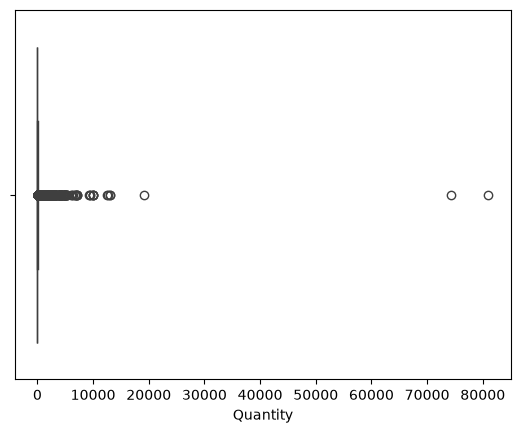

In [35]:
sns.boxplot(x = df['Quantity'])

<Axes: xlabel='Price'>

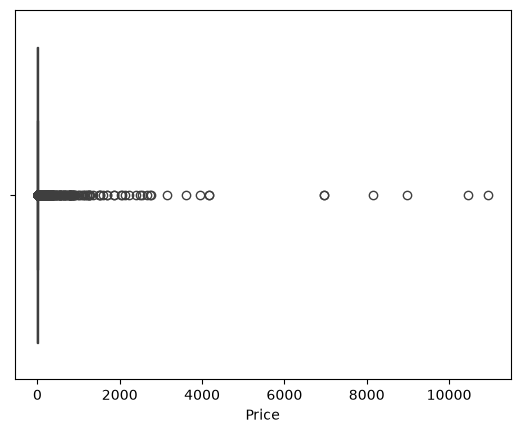

In [36]:
sns.boxplot(x = df['Price'])

<Axes: xlabel='Sales'>

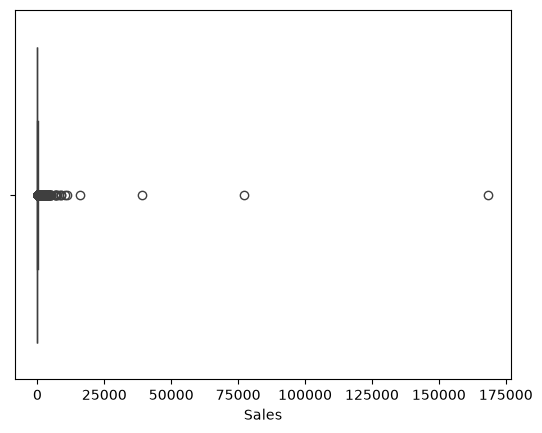

In [37]:
sns.boxplot(x = df['Sales'])

<Axes: >

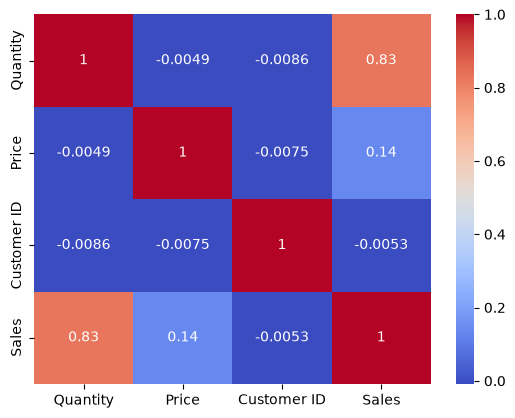

In [38]:
sns.heatmap(df.corr(numeric_only=True), annot = True, cmap = 'coolwarm')

<Axes: >

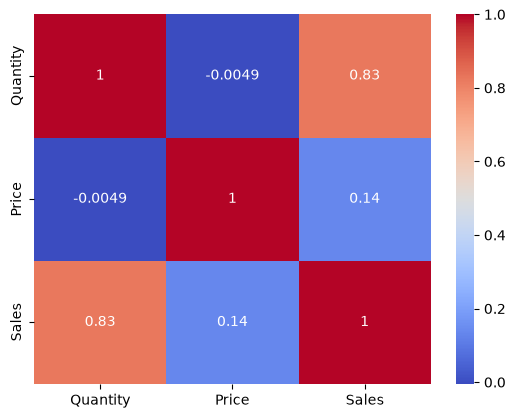

In [39]:
heatmap_df = df[
    ["Quantity","Price","Sales"]
]

sns.heatmap(
    heatmap_df.corr(),
    annot=True,
    cmap="coolwarm"
)

In [40]:
#Group by Product

top_products = (
    df.groupby("Description")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
Name: Sales, dtype: float64


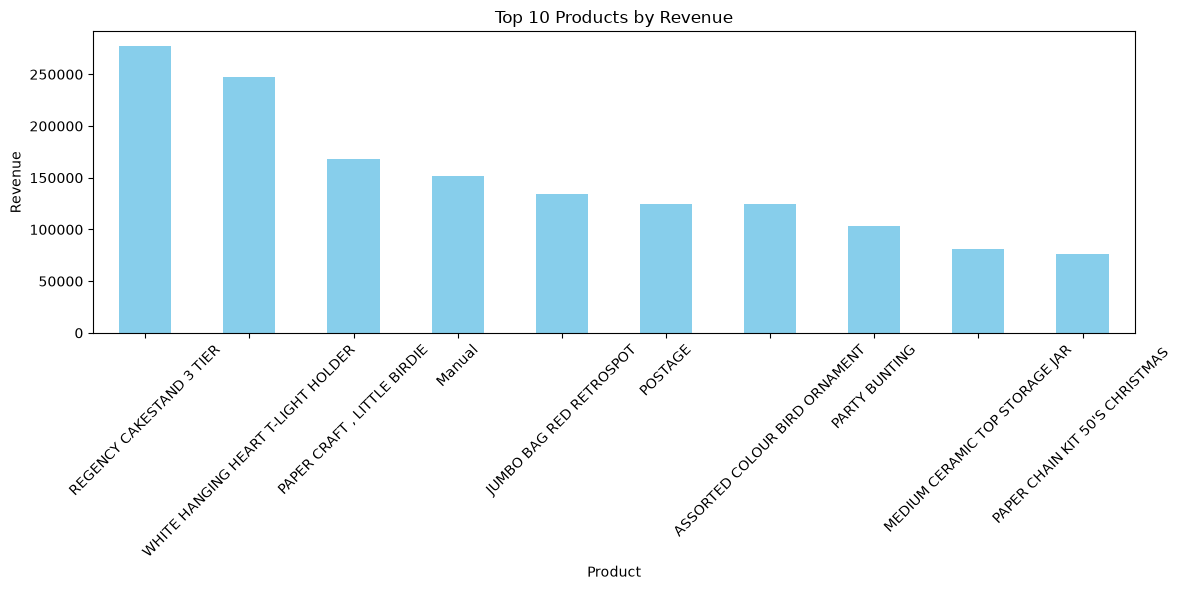

In [41]:
plt.figure(figsize=(12,6))

top_products.plot(
    kind="bar",
    color="skyblue"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [42]:
# Top 10 Countries by Revenue
country_sales = (
    df.groupby("Country")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(country_sales)

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: Sales, dtype: float64


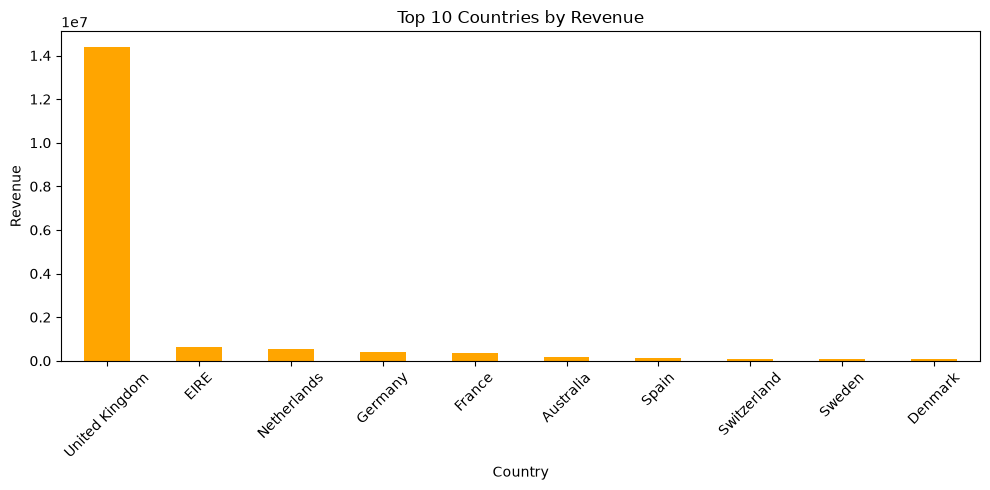

In [43]:
plt.figure(figsize=(10,5))

country_sales.plot(
    kind="bar",
    color="orange"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [44]:
#Monthly Sales Trend
#Create Month
df["Month"] = (
    df["InvoiceDate"]
    .dt.to_period("M")
)

#Aggregate revenue
monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
)

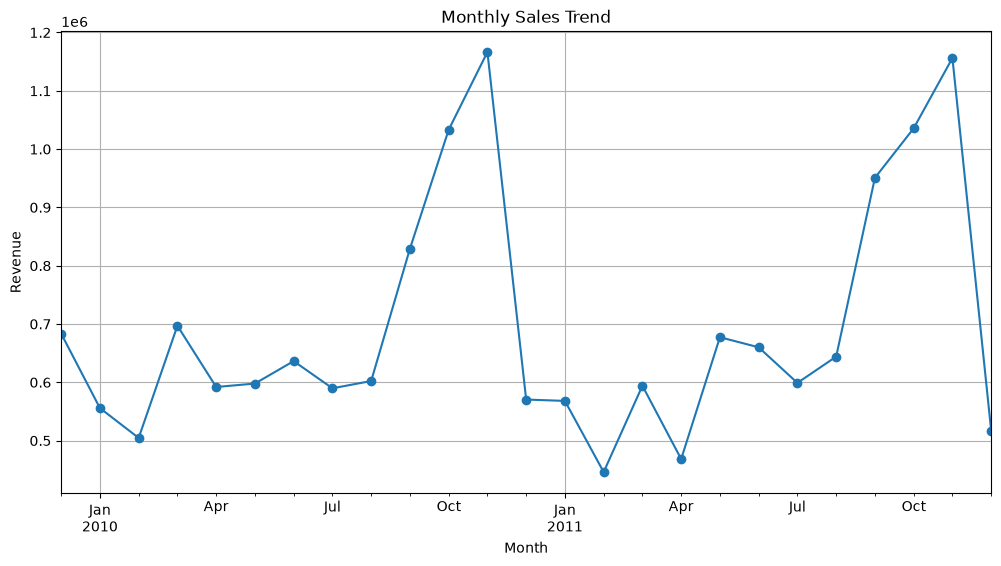

In [45]:
plt.figure(figsize=(12,6))

monthly_sales.plot(
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [46]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales,Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


In [48]:
df.info()

<class 'pandas.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  str           
 1   StockCode    779425 non-null  str           
 2   Description  779425 non-null  str           
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[us]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  str           
 8   Sales        779425 non-null  float64       
 9   Month        779425 non-null  period[M]     
dtypes: datetime64[us](1), float64(3), int64(1), period[M](1), str(4)
memory usage: 65.4 MB


In [49]:
import os
os.makedirs(
    "../Data/Processed",
    exist_ok=True
)
#Save clean Data
df.to_csv(
    "Data/Processed/cleaned_data.csv",
    index=False
)